In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [3]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-05'

In [4]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_haa'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]}
}


selection = {
    'nocuts' : "All events"
}

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json",
                 "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [17]:
if os.path.isdir(outdir) :
    pass
else :
    os.makedirs(outdir)

In [5]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [6]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [7]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [8]:
# ok now I want to plot b-jets and photons variables
selection = {
    "nocuts" : "All events",
}
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList

In [9]:
variables_list = [
            # reco photons from Higgs
            "n_photons_from_higgs", 
            "HtoYY_E_y1", "HtoYY_pT_y1", "HtoYY_eta_y1", "HtoYY_phi_y1", "HtoYY_has_higgs_parent_y1",
            "HtoYY_E_y2", "HtoYY_pT_y2", "HtoYY_eta_y2", "HtoYY_phi_y2", "HtoYY_has_higgs_parent_y2",
            "HtoYY_m_yy", "HtoYY_DR_y_y", "HtoYY_pT_yy",
            "HtoYY_iso_y1", "HtoYY_iso_y2",
            # reco-to-truth particle association for photons from Higgs
             "HtoYY_true_E_y1", "HtoYY_true_pT_y1", "HtoYY_true_eta_y1", "HtoYY_true_phi_y1",
             "HtoYY_true_E_y2", "HtoYY_true_pT_y2", "HtoYY_true_eta_y2", "HtoYY_true_phi_y2",    
             "HtoYY_true_m_yy", "HtoYY_true_pT_yy", "HtoYY_true_DR_y_y",
            # truth photons from Higgs
             "HtoYY_n_truth_photons", "HtoYY_truth_m_yy",
             "HtoYY_truth_E_y1", "HtoYY_truth_pT_y1", "HtoYY_truth_eta_y1", "HtoYY_truth_phi_y1",
             "HtoYY_truth_E_y2", "HtoYY_truth_pT_y2", "HtoYY_truth_eta_y2", "HtoYY_truth_phi_y2", 'weight'
]

In [10]:
df = {}
sow = {}

In [11]:
for p in process.keys() :
    if p in list(df.keys()) :
        pass
    else :
        df[p] = {}
    print(p)
    variable_list1 = variables_list + ['pT_higgs'] if p=='ttHyy' else variables_list
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                f = ROOT.TFile.Open(inputfile)
                sow[p].append(f.Get("SumOfWeights").GetVal())
                f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    df1.append(ak.to_dataframe(f['events'].arrays(expressions=variable_list1, library='ak')))
                    df1[-1]["weight"] = df1[-1]["weight"]/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)

ttHyy
		nocuts


In [13]:
process_key = list(process.keys())[0]
process_label = process[process_key]['label']
sel_key = list(selection.keys())[0]
sel_label = selection[sel_key]

In [14]:
df1 = df[process_key][sel_key].copy()

<Axes: >

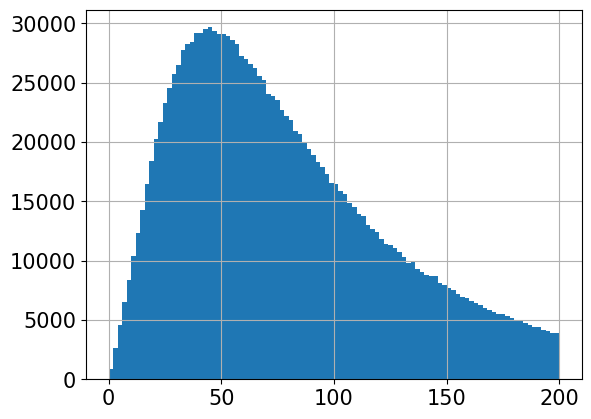

In [80]:
df1["HtoYY_truth_pT_y2"].hist(range=(0,200), bins=100)

In [83]:
len(df1[(df1["HtoYY_truth_pT_y2"]<10.) & (df1["HtoYY_truth_pT_y2"]>=0)])/len(df1[df1["HtoYY_truth_pT_y2"]>=0])

0.013561924863410606

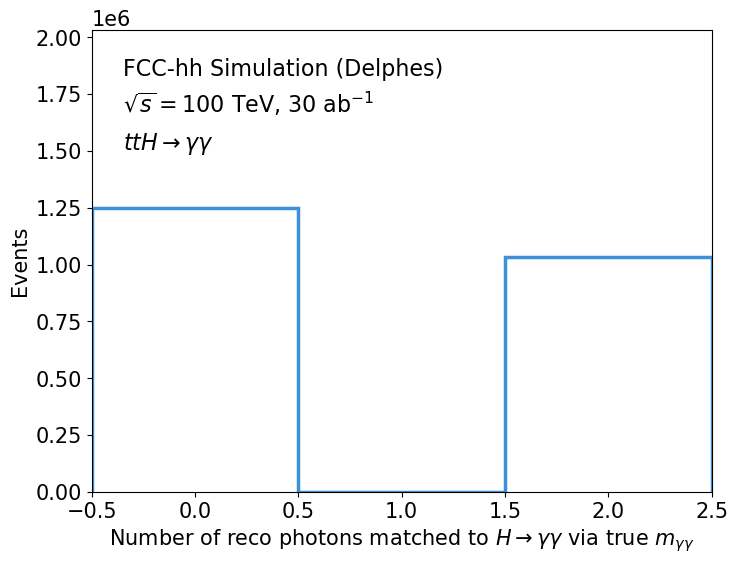

In [21]:
# plot the myy distribution for each category
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

# plot number of reco photons from Higgs using the Myy algorithm
bin_values, bin_edges, _ = ax.hist(df1["n_photons_from_higgs"], weights=df1["weight"]*lumi,
        bins=3, range=(-0.5,2.5),
        histtype='step', linewidth=2.5, color=color_sequence[0])

# uncertainty
x = 0.5*(bin_edges[1:]+bin_edges[:-1])
xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
bin_unc, _ = np.histogram(df1["n_photons_from_higgs"], weights=(df1["weight"]*lumi)**2, bins=3, range=(-0.5,2.5))
bin_unc = np.sqrt(bin_unc)
error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[0])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)

#ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

xlabel = r"Number of reco photons matched to $H\rightarrow \gamma\gamma$ via true $m_{\gamma\gamma}$"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(-0.5,2.5)
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.55)
    
plotname = "photons_from_higgs_via_m_yy_number"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [ ]:
df3 = 
df4 =

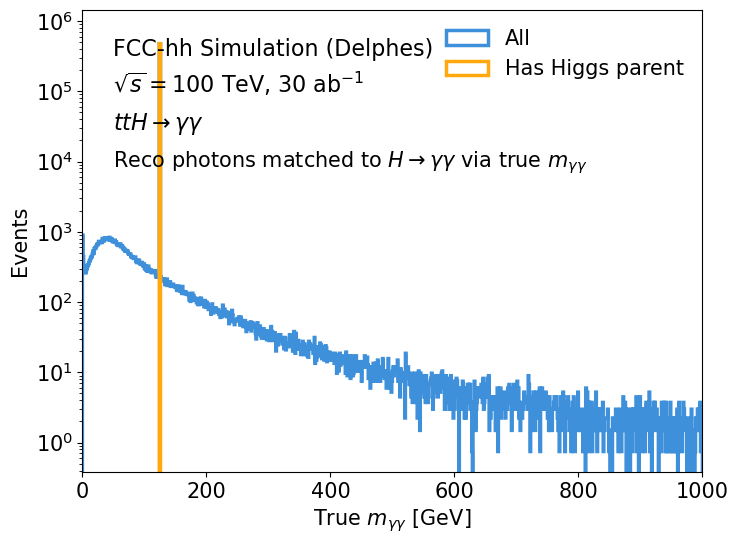

In [69]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

# plot true myy of reco photons from Higgs using the Myy algorithm
bin_values, bin_edges, _ = ax.hist(df1["HtoYY_true_m_yy"], weights=df1["weight"]*lumi,
        bins=1000, range=(0,1000),
        histtype='step', linewidth=2.5, color=color_sequence[0], label="All")

df2 = df1[(df1['HtoYY_has_higgs_parent_y1']==1) & (df1['HtoYY_has_higgs_parent_y2']==1)]
bin_values, bin_edges, _ = ax.hist(df2["HtoYY_true_m_yy"], weights=df2["weight"]*lumi,
        bins=1000, range=(0,1000),
        histtype='step', linewidth=2.5, color=color_sequence[1], label="Has Higgs parent")
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.66, r"Reco photons matched to $H\rightarrow \gamma\gamma$ via true $m_{\gamma\gamma}$", transform=ax.transAxes, fontsize=15)
#ax.text(0.05, 0.68, "via $m_{\gamma\gamma}$", transform=ax.transAxes, fontsize=15)

ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

xlabel = "True $m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_yscale("log")
ax.set_xlim(0,1000)
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.55)
plotname = "photons_from_higgs_via_m_yy_no_cuts_true_m_yy_log"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

# plot true myy of reco photons from Higgs using the Myy algorithm
bin_values, bin_edges, _ = ax.hist(df1["HtoYY_true_m_yy"], weights=df1["weight"]*lumi,
        bins=1000, range=(0,1000),
        histtype='step', linewidth=2.5, color=color_sequence[0])

# uncertainty
x = 0.5*(bin_edges[1:]+bin_edges[:-1])
xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
bin_unc, _ = np.histogram(df1["HtoYY_true_m_yy"], weights=(df1["weight"]*lumi)**2,bins=1000, range=(0,1000))
bin_unc = np.sqrt(bin_unc)
error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[0])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.66, r"Reco photons matched to $H\rightarrow \gamma\gamma$ via true $m_{\gamma\gamma}$", transform=ax.transAxes, fontsize=15)
ax.text(0.05, 0.60, "", transform=ax.transAxes, fontsize=15)

ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

xlabel = "True $m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_yscale("log")
ax.set_xlim(0,1000)
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.55)
plotname = "photons_from_higgs_via_m_yy_no_cuts_true_m_yy_log1"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [64]:
len(df1[(df1["HtoYY_true_m_yy"]<124) | (df1["HtoYY_true_m_yy"]>126)])/len(df1)

0.5842052306000681

/tmp/elmazzeo/ipykernel_3743862/1908884263.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


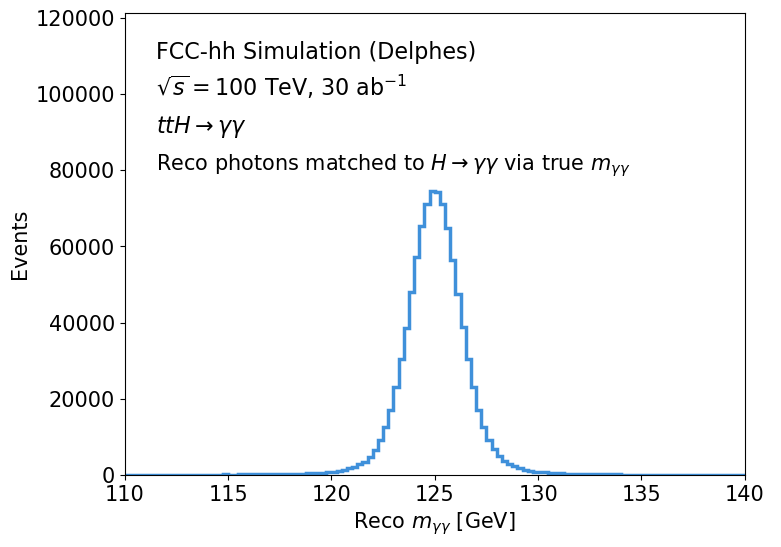

In [33]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

# plot true myy of reco photons from Higgs using the Myy algorithm
bin_values, bin_edges, _ = ax.hist(df1["HtoYY_m_yy"], weights=df1["weight"]*lumi,
        bins=120, range=(110,140),
        histtype='step', linewidth=2.5, color=color_sequence[0])

# uncertainty
x = 0.5*(bin_edges[1:]+bin_edges[:-1])
xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
bin_unc, _ = np.histogram(df1["HtoYY_m_yy"], weights=(df1["weight"]*lumi)**2, bins=120, range=(110,140))
bin_unc = np.sqrt(bin_unc)
error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[0])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.66, r"Reco photons matched to $H\rightarrow \gamma\gamma$ via true $m_{\gamma\gamma}$", transform=ax.transAxes, fontsize=15)
#ax.text(0.05, 0.68, "via $m_{\gamma\gamma}$", transform=ax.transAxes, fontsize=15)

ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

xlabel = "Reco $m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(110,140)
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.55)
    
plotname = "photons_from_higgs_via_m_yy_no_cuts_m_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [34]:
df_y1 = df1[['HtoYY_has_higgs_parent_y1', 'weight']]
df_y2 = df1[['HtoYY_has_higgs_parent_y2', 'weight']]

In [43]:
df_y1= df_y1.rename(columns={'HtoYY_has_higgs_parent_y1' : 'HtoYY_has_higgs_parent'})
df_y2= df_y2.rename(columns={'HtoYY_has_higgs_parent_y2' : 'HtoYY_has_higgs_parent'})

In [44]:
df_y = pd.concat([df_y1,df_y2], copy=False, ignore_index=True)

In [45]:
df_y.head()

,HtoYY_has_higgs_parent,weight
0,True,2.485530e-08
1,False,2.485530e-08
2,True,2.485530e-08
3,True,2.485530e-08
4,True,2.485530e-08


/cvmfs/sw.hsf.org/key4hep/releases/2024-10-03/x86_64-almalinux9-gcc14.2.0-opt/py-matplotlib/3.9.2-es64w5/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/elmazzeo/ipykernel_3743862/1136416780.py:15: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bin_unc, _ = np.histogram(df_y["HtoYY_has_higgs_parent"], weights=(df_y["weight"]*lumi)**2, bins=2, range=(-0.5,1.5))
/tmp/elmazzeo/ipykernel_3743862/1136416780.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


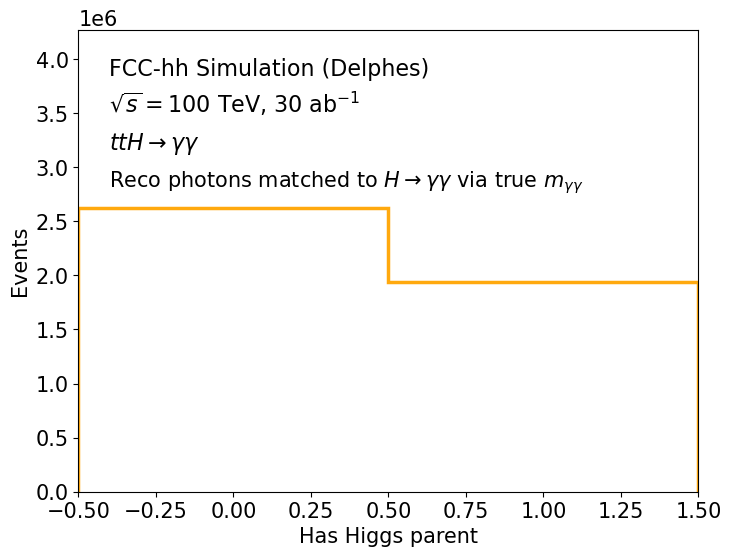

In [47]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

# plot the flag Has Higgs Parent for reco photons matched to H->yy via myy
bin_values, bin_edges, _ = ax.hist(df_y["HtoYY_has_higgs_parent"], weights=df_y["weight"]*lumi,
        bins=2, range=(-0.5,1.5),
        histtype='step', linewidth=2.5, color=color_sequence[1])

# uncertainty
x = 0.5*(bin_edges[1:]+bin_edges[:-1])
xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
bin_unc, _ = np.histogram(df_y["HtoYY_has_higgs_parent"], weights=(df_y["weight"]*lumi)**2, bins=2, range=(-0.5,1.5))
bin_unc = np.sqrt(bin_unc)
error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[1])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.66, r"Reco photons matched to $H\rightarrow \gamma\gamma$ via true $m_{\gamma\gamma}$", transform=ax.transAxes, fontsize=15)
#ax.text(0.05, 0.68, "via $m_{\gamma\gamma}$", transform=ax.transAxes, fontsize=15)

ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

xlabel = "Has Higgs parent"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(-0.5,1.5)
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.55)
    
plotname = "photons_from_higgs_via_m_yy_no_cuts_has_higgs_parent"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

/tmp/elmazzeo/ipykernel_3743862/3897970808.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


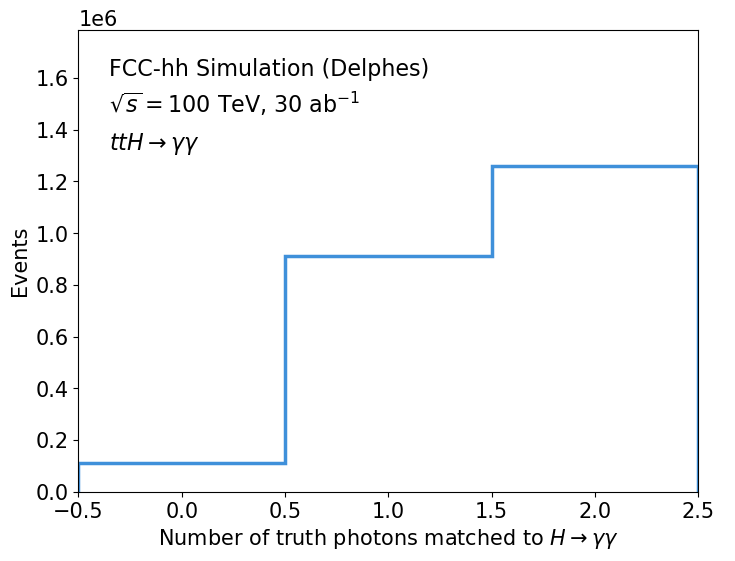

In [51]:
# plot the myy distribution for each category
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

# plot number of reco photons from Higgs using the Myy algorithm
bin_values, bin_edges, _ = ax.hist(df1["HtoYY_n_truth_photons"], weights=df1["weight"]*lumi,
        bins=3, range=(-0.5,2.5),
        histtype='step', linewidth=2.5, color=color_sequence[0])

# uncertainty
x = 0.5*(bin_edges[1:]+bin_edges[:-1])
xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
bin_unc, _ = np.histogram(df1["n_photons_from_higgs"], weights=(df1["weight"]*lumi)**2, bins=3, range=(-0.5,2.5))
bin_unc = np.sqrt(bin_unc)
error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[0])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

xlabel = r"Number of truth photons matched to $H\rightarrow \gamma\gamma$"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(-0.5,2.5)
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "truth_photons_from_higgs_number"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [72]:
df1["n_photons_from_higgs"].min()

0

In [52]:
df2 = df1[df1['n_photons_from_higgs']>=2]

In [53]:
variables_to_plot = ['E_y1', 'pT_y1', 'eta_y1', 'phi_y1',
                    'E_y2', 'pT_y2', 'eta_y2', 'phi_y2']
variables_labels = ['$E(\gamma_1)$ [GeV]', "$p_T(\gamma_1)$ [GeV]", "$\eta(\gamma_1)$", "$\phi(\gamma_1)$",
                  '$E(\gamma_2)$ [GeV]', "$p_T(\gamma_2)$ [GeV]", "$\eta(\gamma_2)$", "$\phi(\gamma_2)$"]

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


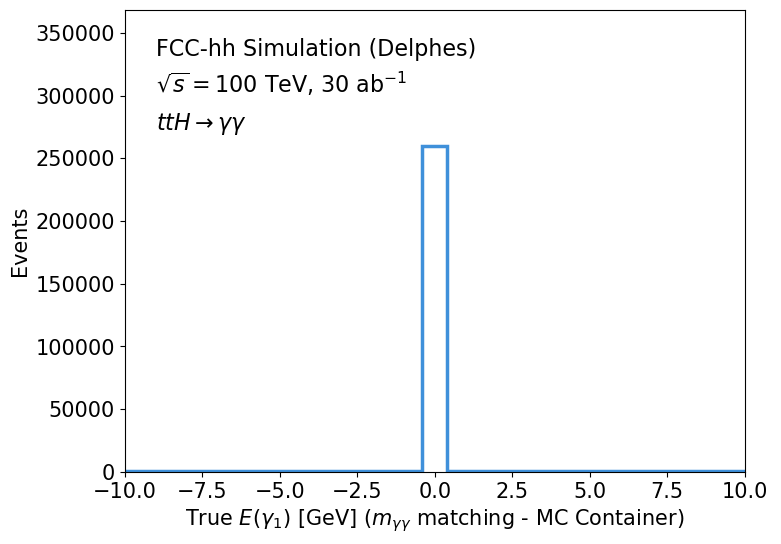

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


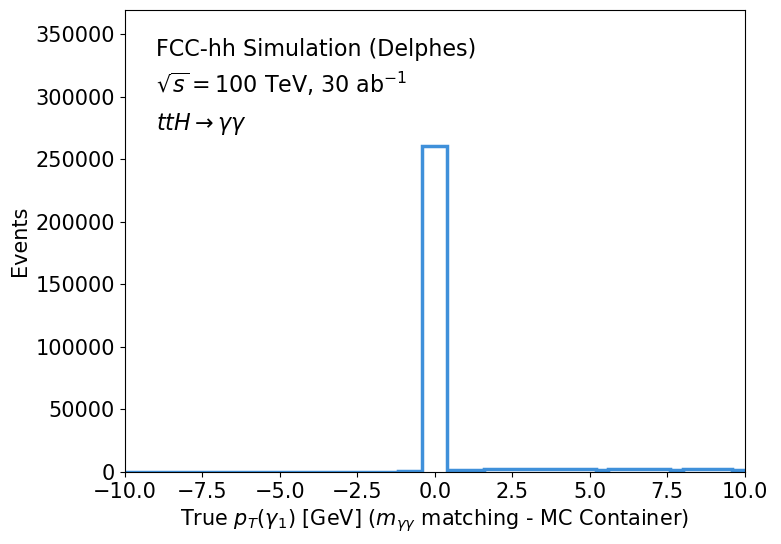

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


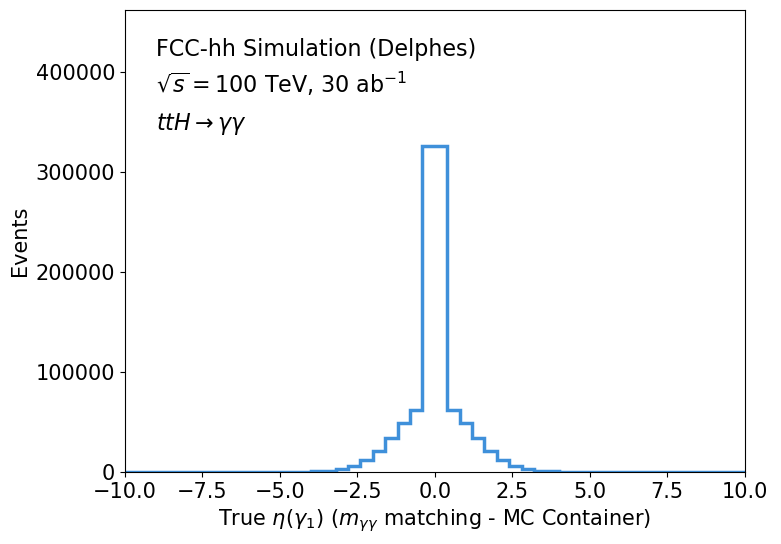

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


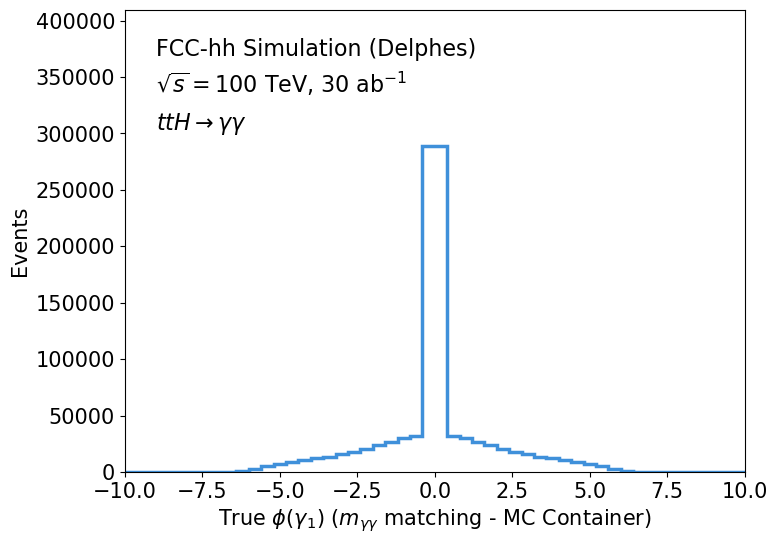

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


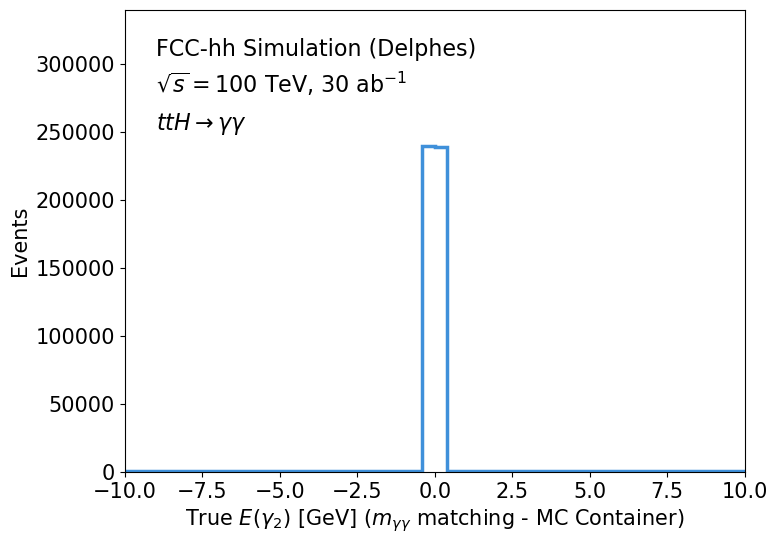

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


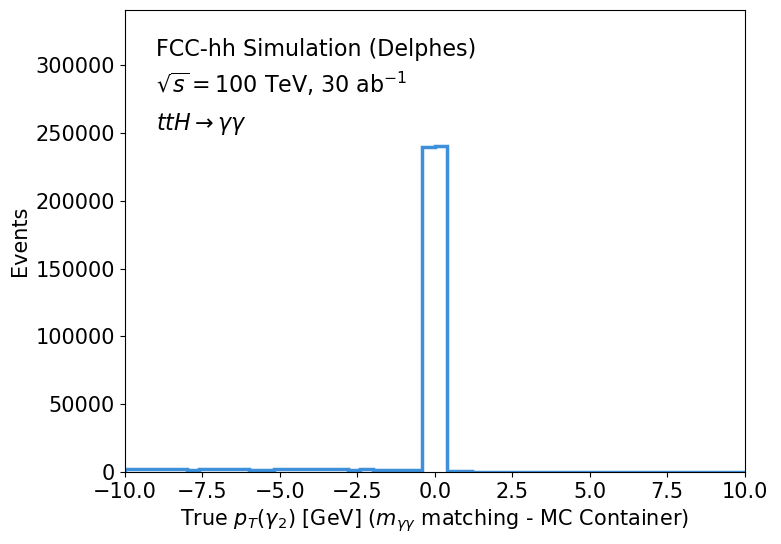

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


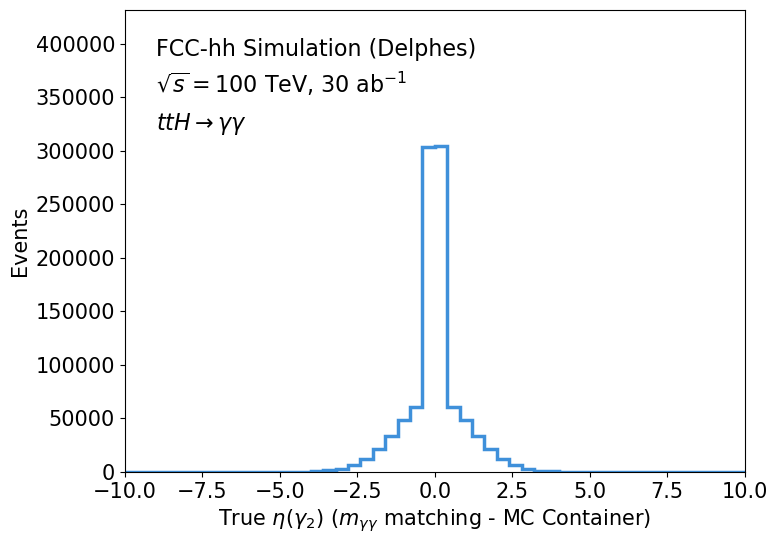

/tmp/elmazzeo/ipykernel_3743862/1077116876.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


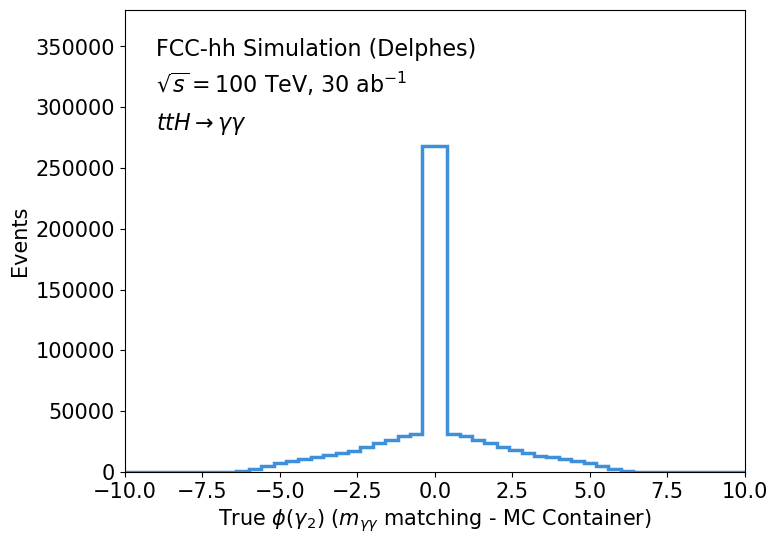

In [55]:
for v, v_label in zip(variables_to_plot, variables_labels) :
    
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )

    # plot number of reco photons from Higgs using the Myy algorithm
    obs = df2["HtoYY_true_"+v]-df2['HtoYY_truth_'+v]
    bin_values, bin_edges, _ = ax.hist(obs, weights=df2["weight"]*lumi,
        bins=50, range=(-10,10),
        histtype='step', linewidth=2.5, color=color_sequence[0])

    # uncertainty
    x = 0.5*(bin_edges[1:]+bin_edges[:-1])
    xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
    bin_unc, _ = np.histogram(obs, weights=(df2["weight"]*lumi)*2, bins=50, range=(-10,10))
    bin_unc = np.sqrt(bin_unc)
    error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[0])
    
    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)

    ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))

    xlabel = "True "+v_label+" ($m_{\gamma\gamma}$ matching - MC Container)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Events')

    ax.set_xlim(-10,10)
    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
    plotname = v+"_diff_truth_photons_from_Higgs"
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()